In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  
import src.csv_io as csv_io 
from pathlib import Path
from src.config import RAW_DIR

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Load all CSV files
data_files = csv_io.read_csv_directory(RAW_DIR)
print(f"Loaded {len(data_files)} tables:")
for name, df in data_files.items():
    print(f"  - {name}: {df.shape}")

Loaded 14 tables:
  - customers: (121930, 7)
  - geography: (39948, 4)
  - inventory: (60247, 17)
  - order_items: (714669, 7)
  - orders: (646945, 8)
  - payments: (646945, 4)
  - products: (2412, 8)
  - promotions: (50, 10)
  - returns: (39939, 7)
  - reviews: (113551, 7)
  - sales: (3833, 3)
  - sample_submission: (548, 3)
  - shipments: (566067, 4)
  - web_traffic: (3652, 7)


## 1. Orders Analysis

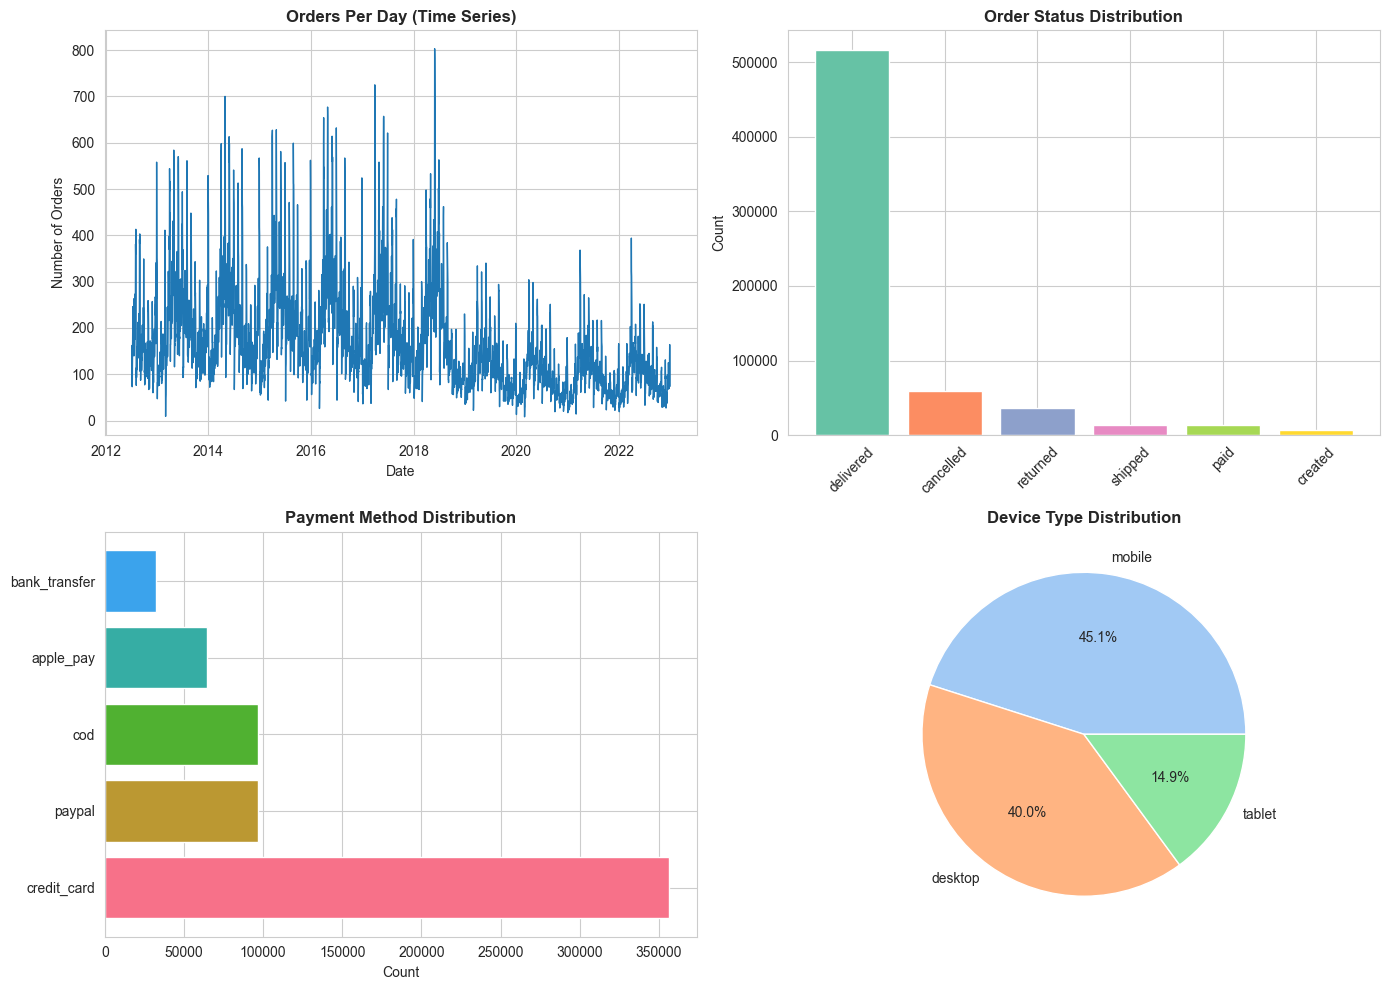

In [3]:
# Orders time series and distribution
orders = data_files['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Orders per day
orders_per_day = orders.groupby(orders['order_date'].dt.date).size()
axes[0, 0].plot(orders_per_day.index, orders_per_day.values, linewidth=1)
axes[0, 0].set_title('Orders Per Day (Time Series)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Orders')

# Order status distribution
order_status = orders['order_status'].value_counts()
axes[0, 1].bar(order_status.index, order_status.values, color=sns.color_palette('Set2'))
axes[0, 1].set_title('Order Status Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Payment method distribution
payment_method = orders['payment_method'].value_counts()
axes[1, 0].barh(payment_method.index, payment_method.values, color=sns.color_palette('husl'))
axes[1, 0].set_title('Payment Method Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Device type
device = orders['device_type'].value_counts()
axes[1, 1].pie(device.values, labels=device.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Device Type Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(RAW_DIR.parent / 'images' / 'eda' / 'orders_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Products & Segments Analysis

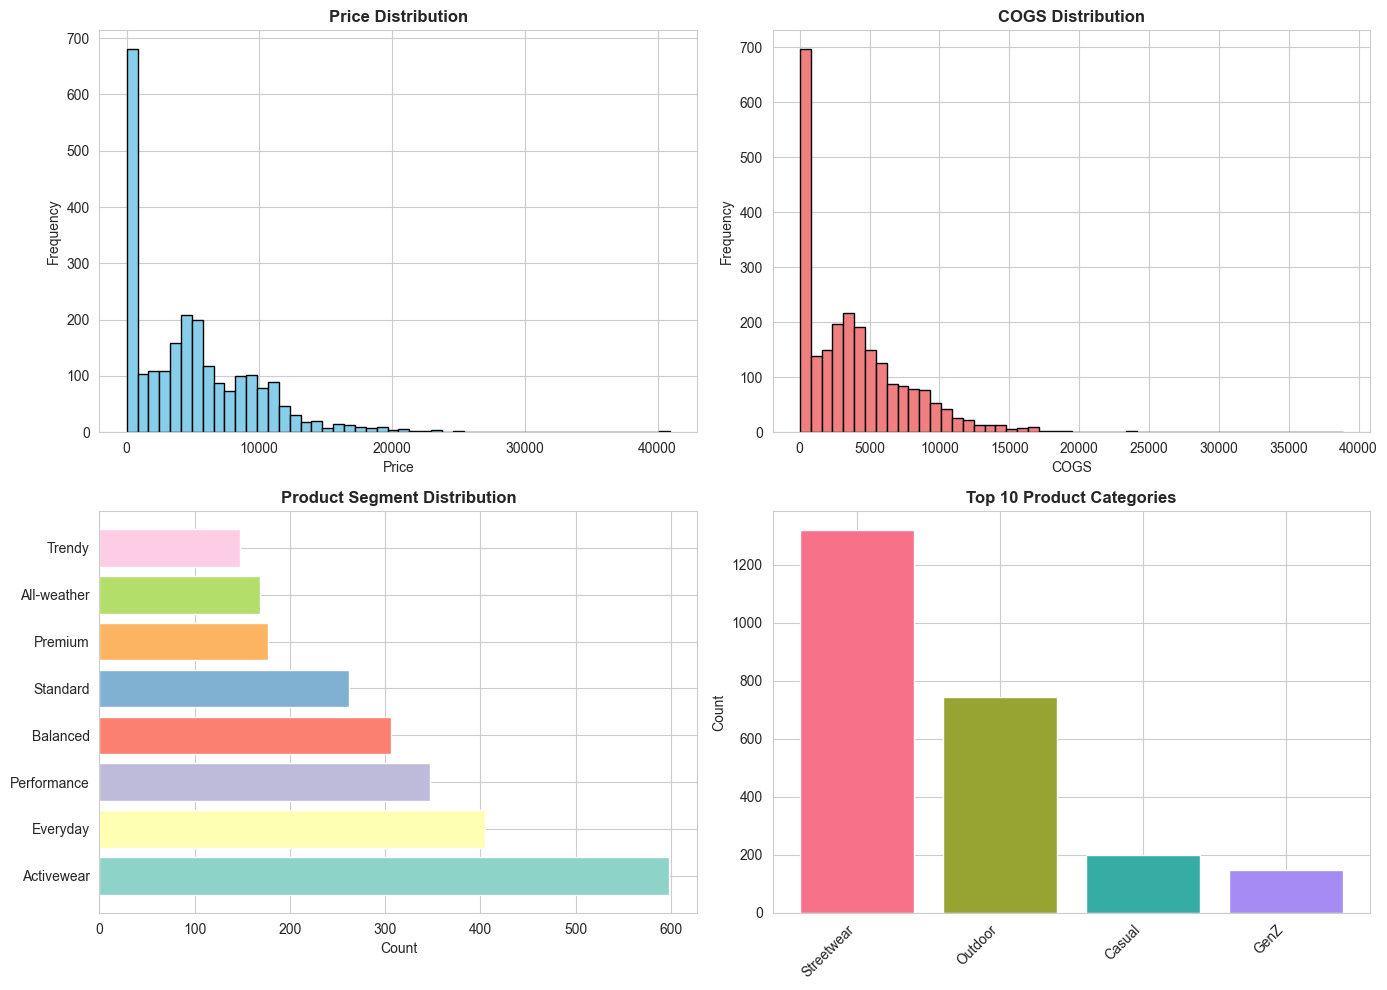

In [4]:
# Products analysis
products = data_files['products'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
axes[0, 0].hist(products['price'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')

# COGS distribution
axes[0, 1].hist(products['cogs'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('COGS Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('COGS')
axes[0, 1].set_ylabel('Frequency')

# Segment distribution
segment = products['segment'].value_counts()
axes[1, 0].barh(segment.index, segment.values, color=sns.color_palette('Set3'))
axes[1, 0].set_title('Product Segment Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Category distribution
category = products['category'].value_counts().head(10)
axes[1, 1].bar(range(len(category)), category.values, color=sns.color_palette('husl', len(category)))
axes[1, 1].set_xticks(range(len(category)))
axes[1, 1].set_xticklabels(category.index, rotation=45, ha='right')
axes[1, 1].set_title('Top 10 Product Categories', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(RAW_DIR.parent / 'images' / 'eda' / 'products_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Customers Analysis

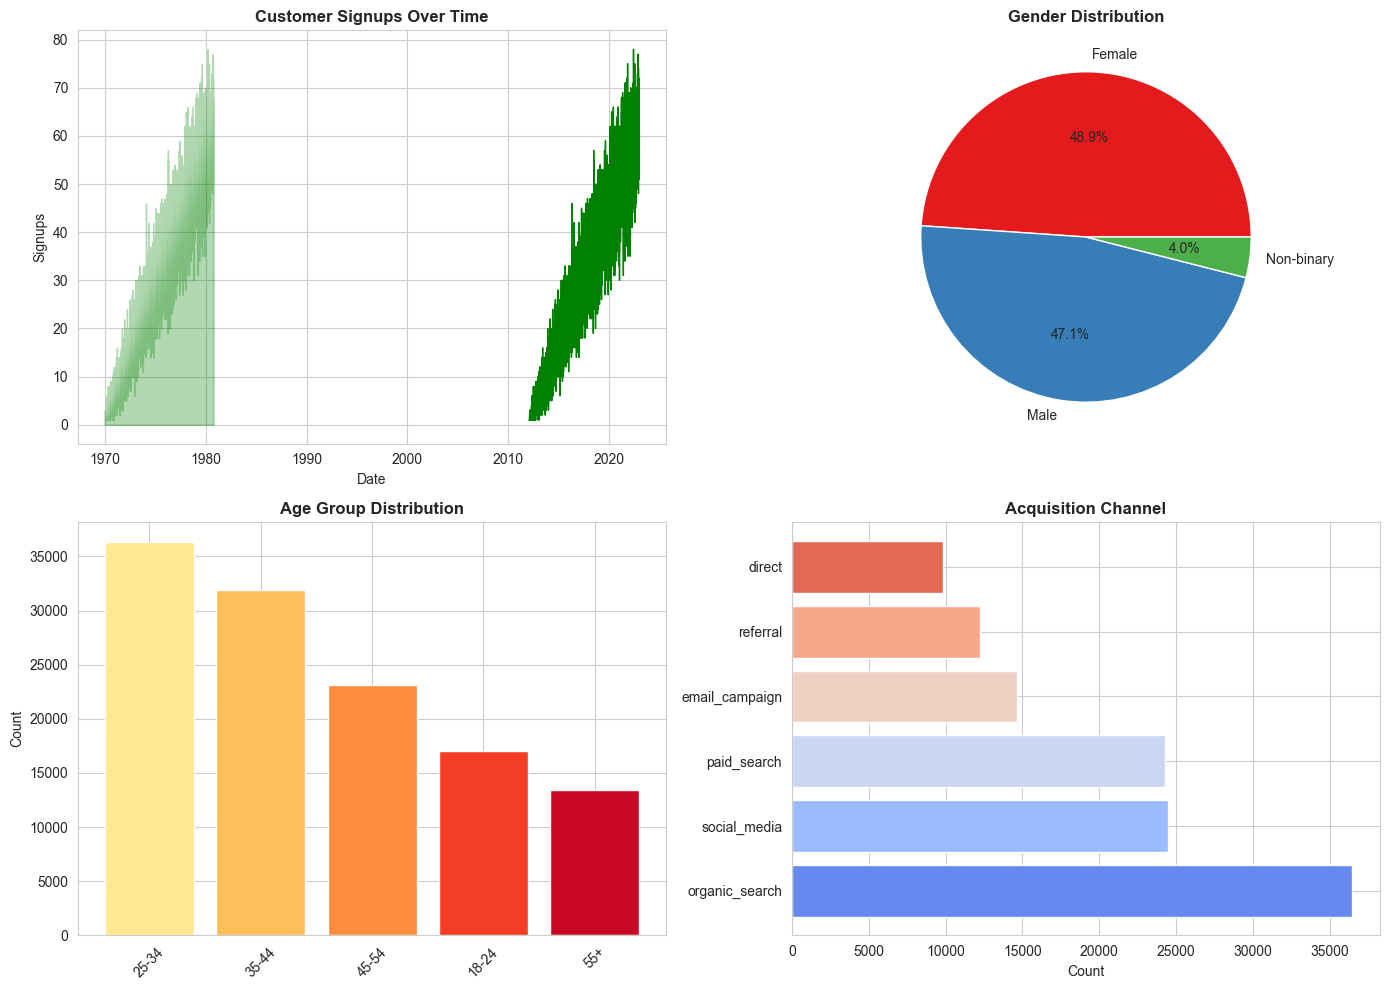

In [5]:
# Customers analysis
customers = data_files['customers'].copy()
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Signup over time
signups_per_day = customers.groupby(customers['signup_date'].dt.date).size()
axes[0, 0].plot(signups_per_day.index, signups_per_day.values, linewidth=1, color='green')
axes[0, 0].fill_between(range(len(signups_per_day)), signups_per_day.values, alpha=0.3, color='green')
axes[0, 0].set_title('Customer Signups Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Signups')

# Gender distribution
if 'gender' in customers.columns:
    gender = customers['gender'].value_counts()
    axes[0, 1].pie(gender.values, labels=gender.index, autopct='%1.1f%%', colors=sns.color_palette('Set1'))
    axes[0, 1].set_title('Gender Distribution', fontsize=12, fontweight='bold')

# Age group distribution
if 'age_group' in customers.columns:
    age_group = customers['age_group'].value_counts()
    axes[1, 0].bar(age_group.index, age_group.values, color=sns.color_palette('YlOrRd', len(age_group)))
    axes[1, 0].set_title('Age Group Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=45)

# Acquisition channel
if 'acquisition_channel' in customers.columns:
    acq = customers['acquisition_channel'].value_counts()
    axes[1, 1].barh(acq.index, acq.values, color=sns.color_palette('coolwarm', len(acq)))
    axes[1, 1].set_title('Acquisition Channel', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(RAW_DIR.parent / 'images' / 'eda' / 'customers_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Order Items & Revenue Analysis

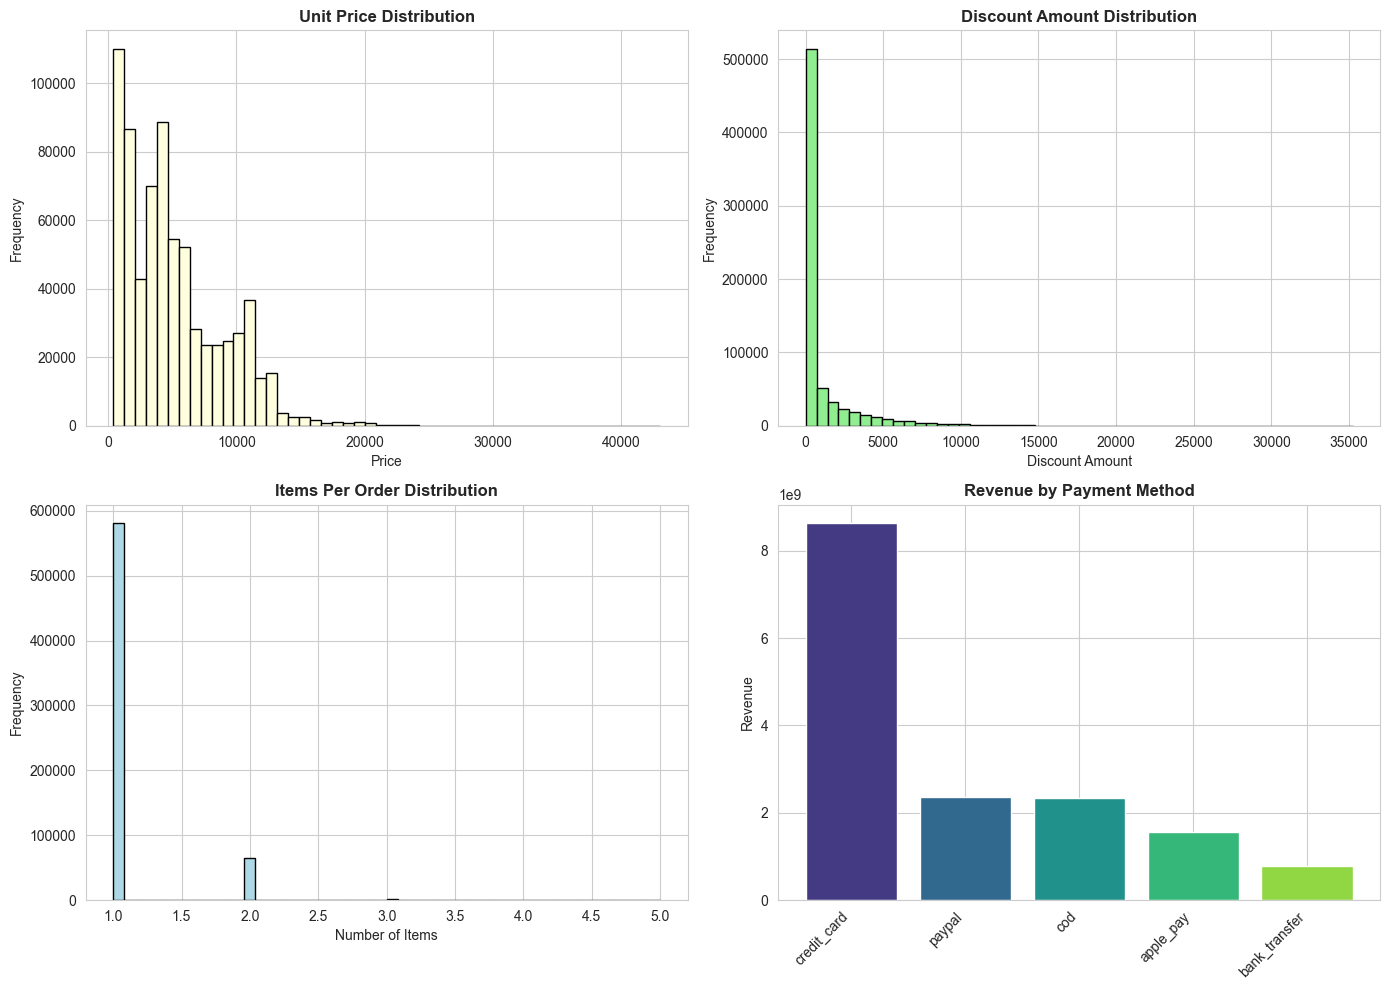

In [6]:
# Order items analysis
order_items = data_files['order_items'].copy()
payments = data_files['payments'].copy() if 'payments' in data_files else None

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Unit price distribution
axes[0, 0].hist(order_items['unit_price'], bins=50, color='lightyellow', edgecolor='black')
axes[0, 0].set_title('Unit Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')

# Discount amount distribution
axes[0, 1].hist(order_items['discount_amount'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Discount Amount Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Discount Amount')
axes[0, 1].set_ylabel('Frequency')

# Quantity per order
quantities = order_items['order_id'].value_counts()
axes[1, 0].hist(quantities.values, bins=50, color='lightblue', edgecolor='black')
axes[1, 0].set_title('Items Per Order Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Items')
axes[1, 0].set_ylabel('Frequency')

# Revenue by payment method (if available)
if payments is not None:
    revenue_by_method = payments.groupby('payment_method')['payment_value'].sum().sort_values(ascending=False)
    axes[1, 1].bar(range(len(revenue_by_method)), revenue_by_method.values, color=sns.color_palette('viridis', len(revenue_by_method)))
    axes[1, 1].set_xticks(range(len(revenue_by_method)))
    axes[1, 1].set_xticklabels(revenue_by_method.index, rotation=45, ha='right')
    axes[1, 1].set_title('Revenue by Payment Method', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig(RAW_DIR.parent / 'images' / 'eda' / 'order_items_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Returns & Quality Analysis

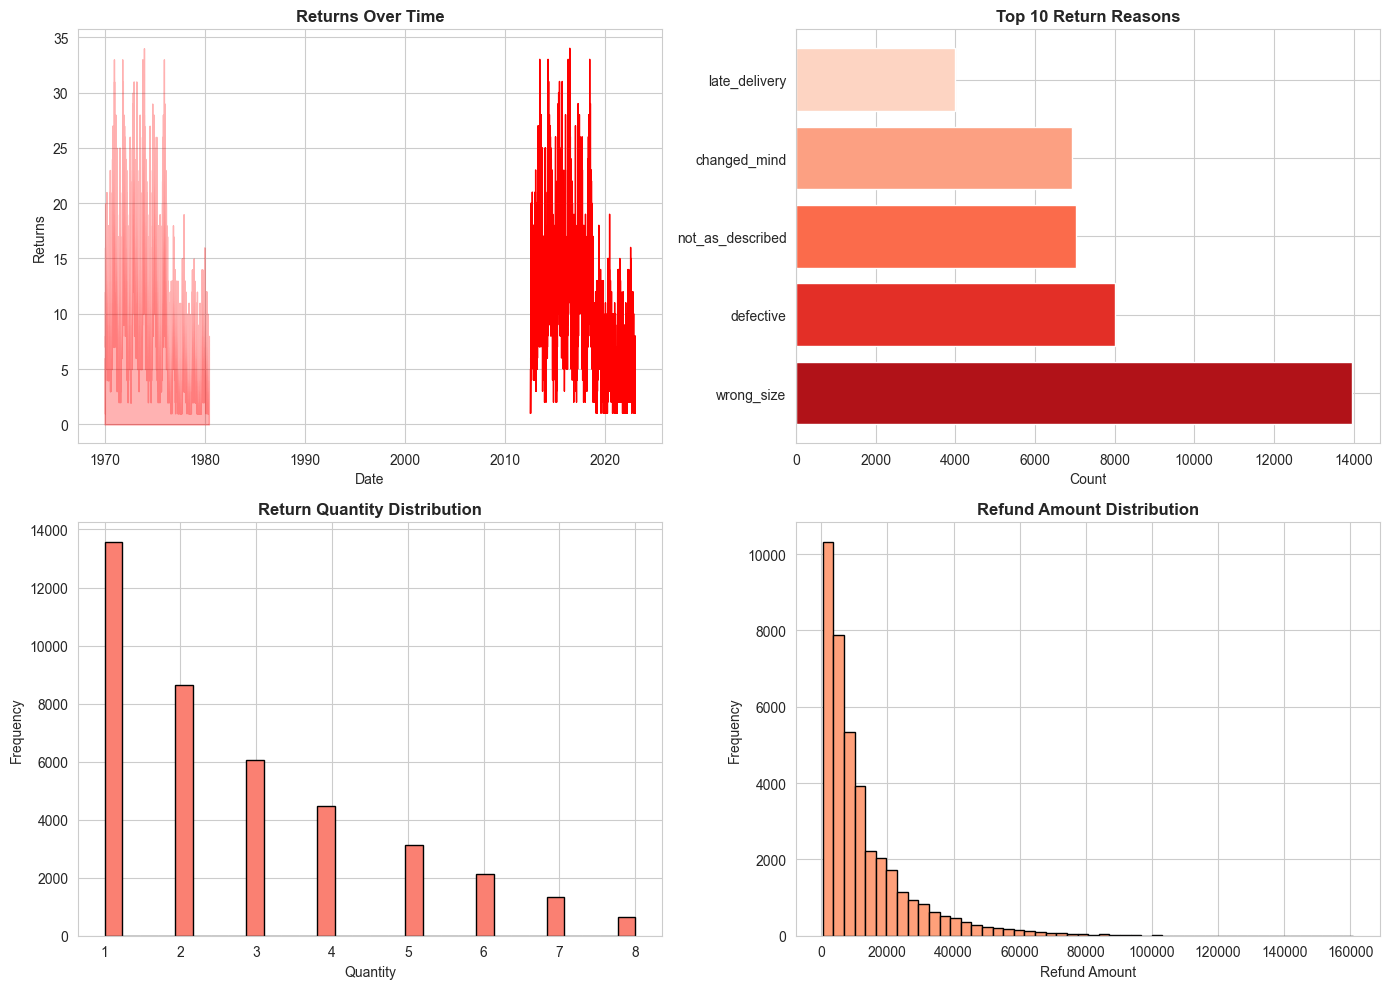


Return Rate: 6.17% (39939 returns out of 646945 orders)


In [7]:
# Returns analysis if available
if 'returns' in data_files:
    returns = data_files['returns'].copy()
    returns['return_date'] = pd.to_datetime(returns['return_date'])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Returns over time
    returns_per_day = returns.groupby(returns['return_date'].dt.date).size()
    axes[0, 0].plot(returns_per_day.index, returns_per_day.values, linewidth=1, color='red')
    axes[0, 0].fill_between(range(len(returns_per_day)), returns_per_day.values, alpha=0.3, color='red')
    axes[0, 0].set_title('Returns Over Time', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Returns')
    
    # Return reason
    if 'return_reason' in returns.columns:
        return_reason = returns['return_reason'].value_counts().head(10)
        axes[0, 1].barh(return_reason.index, return_reason.values, color=sns.color_palette('Reds_r', len(return_reason)))
        axes[0, 1].set_title('Top 10 Return Reasons', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Count')
    
    # Return quantity distribution
    if 'return_quantity' in returns.columns:
        axes[1, 0].hist(returns['return_quantity'], bins=30, color='salmon', edgecolor='black')
        axes[1, 0].set_title('Return Quantity Distribution', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Quantity')
        axes[1, 0].set_ylabel('Frequency')
    
    # Refund amount distribution
    if 'refund_amount' in returns.columns:
        axes[1, 1].hist(returns['refund_amount'], bins=50, color='lightsalmon', edgecolor='black')
        axes[1, 1].set_title('Refund Amount Distribution', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Refund Amount')
        axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig(RAW_DIR.parent / 'images' / 'eda' / 'returns_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Return rate
    total_orders = len(orders)
    total_returns = len(returns)
    return_rate = (total_returns / total_orders) * 100
    print(f"\nReturn Rate: {return_rate:.2f}% ({total_returns} returns out of {total_orders} orders)")

## 6. Reviews & Customer Satisfaction

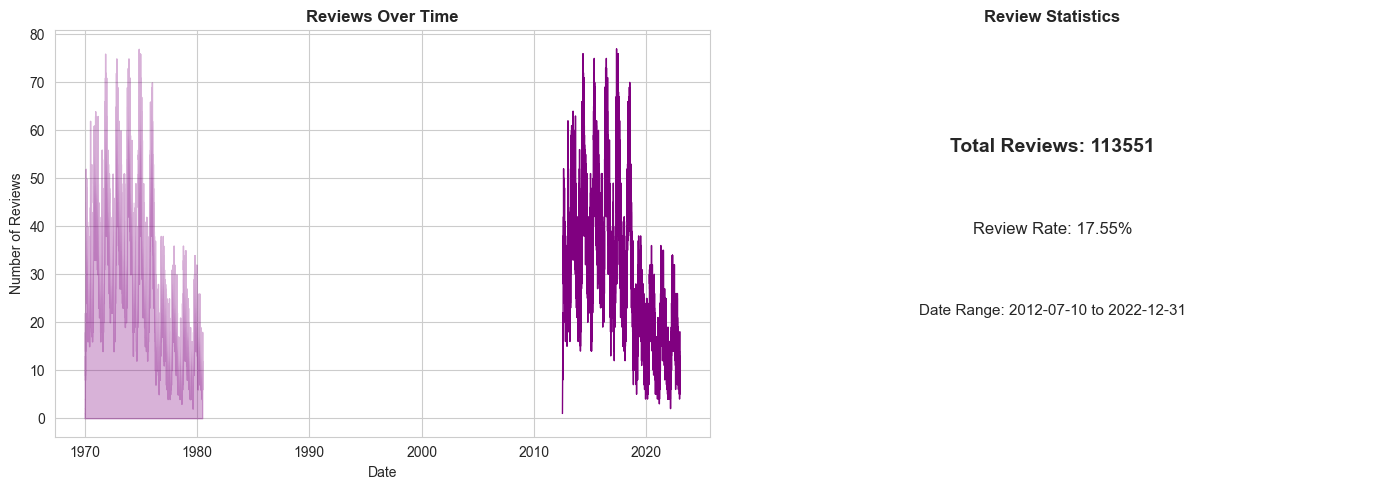

In [8]:
# Reviews analysis if available
if 'reviews' in data_files:
    reviews = data_files['reviews'].copy()
    reviews['review_date'] = pd.to_datetime(reviews['review_date'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Reviews over time
    reviews_per_day = reviews.groupby(reviews['review_date'].dt.date).size()
    axes[0].plot(reviews_per_day.index, reviews_per_day.values, linewidth=1, color='purple')
    axes[0].fill_between(range(len(reviews_per_day)), reviews_per_day.values, alpha=0.3, color='purple')
    axes[0].set_title('Reviews Over Time', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Number of Reviews')
    
    # Review stats
    review_count = len(reviews)
    axes[1].text(0.5, 0.7, f'Total Reviews: {review_count}', ha='center', fontsize=14, fontweight='bold')
    axes[1].text(0.5, 0.5, f'Review Rate: {(review_count / total_orders * 100):.2f}%', ha='center', fontsize=12)
    axes[1].text(0.5, 0.3, f'Date Range: {reviews["review_date"].min().date()} to {reviews["review_date"].max().date()}', ha='center', fontsize=11)
    axes[1].axis('off')
    axes[1].set_title('Review Statistics', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(RAW_DIR.parent / 'images' / 'eda' / 'reviews_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()

## 7. Inventory & Stock Analysis

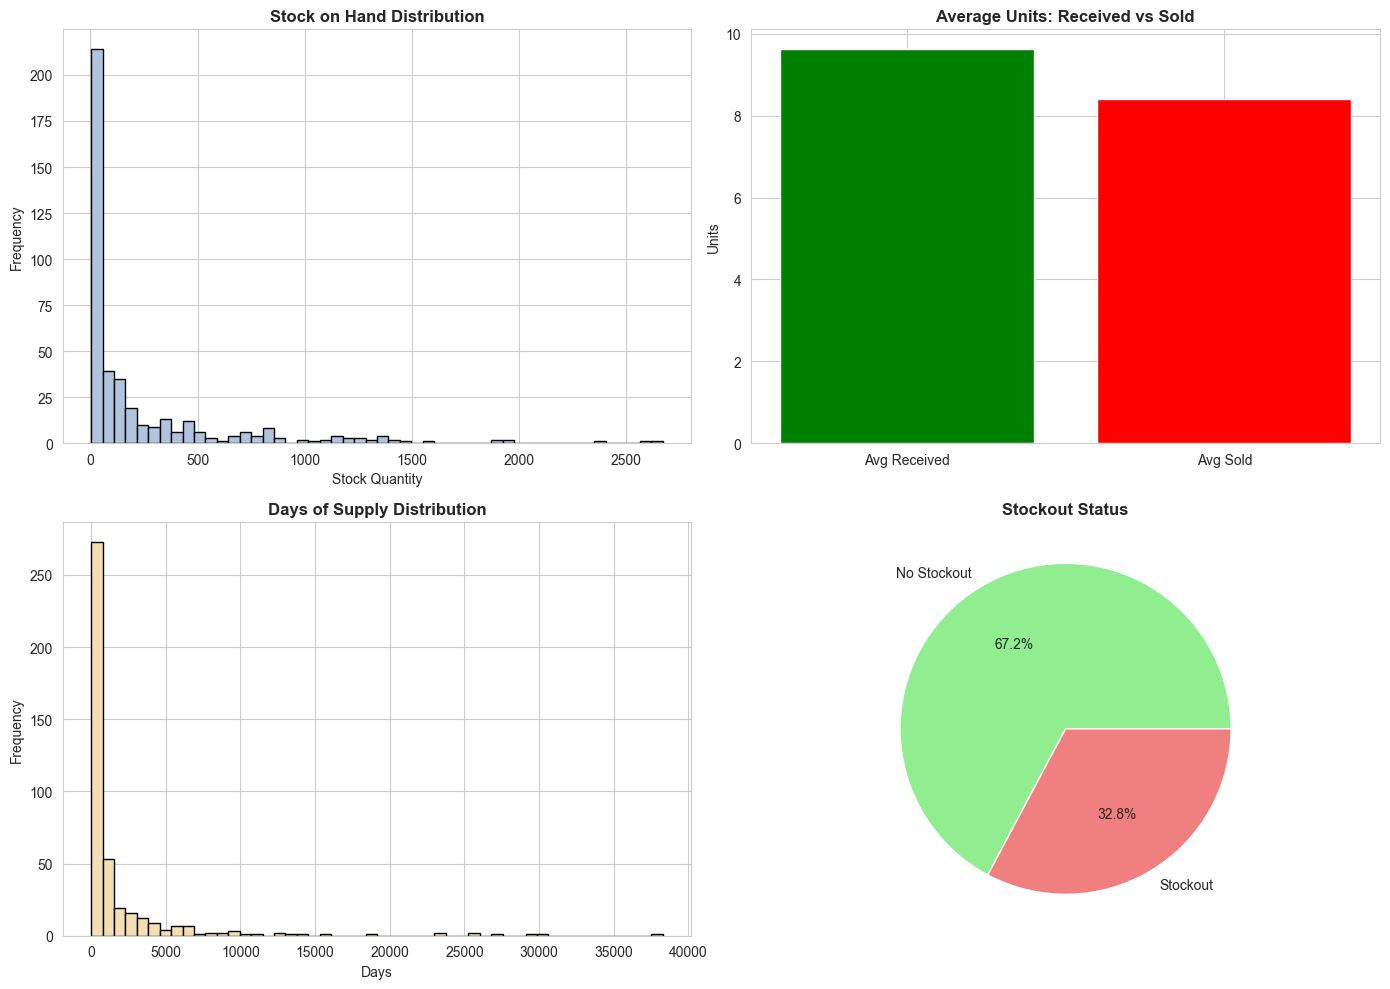

In [9]:
# Inventory analysis if available
if 'inventory' in data_files:
    inventory = data_files['inventory'].copy()
    inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
    
    # Latest snapshot
    latest_inventory = inventory[inventory['snapshot_date'] == inventory['snapshot_date'].max()]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Stock distribution
    if 'stock_on_hand' in latest_inventory.columns:
        axes[0, 0].hist(latest_inventory['stock_on_hand'], bins=50, color='lightsteelblue', edgecolor='black')
        axes[0, 0].set_title('Stock on Hand Distribution', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Stock Quantity')
        axes[0, 0].set_ylabel('Frequency')
    
    # Units received vs sold
    if 'units_received' in latest_inventory.columns and 'units_sold' in latest_inventory.columns:
        avg_received = latest_inventory['units_received'].mean()
        avg_sold = latest_inventory['units_sold'].mean()
        axes[0, 1].bar(['Avg Received', 'Avg Sold'], [avg_received, avg_sold], color=['green', 'red'])
        axes[0, 1].set_title('Average Units: Received vs Sold', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Units')
    
    # Days of supply
    if 'days_of_supply' in latest_inventory.columns:
        axes[1, 0].hist(latest_inventory['days_of_supply'], bins=50, color='wheat', edgecolor='black')
        axes[1, 0].set_title('Days of Supply Distribution', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Days')
        axes[1, 0].set_ylabel('Frequency')
    
    # Stockout flags
    if 'stockout_flag' in latest_inventory.columns:
        stockout = latest_inventory['stockout_flag'].value_counts()
        axes[1, 1].pie(stockout.values, labels=['No Stockout', 'Stockout'], autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
        axes[1, 1].set_title('Stockout Status', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(RAW_DIR.parent / 'images' / 'eda' / 'inventory_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()

## 8. Data Quality Summary

In [10]:
# Data quality summary
print("\n" + "="*60)
print("DATA QUALITY SUMMARY")
print("="*60)

for table_name, df in data_files.items():
    print(f"\n{table_name.upper()}:")
    print(f"  Shape: {df.shape}")
    print(f"  Missing values: {df.isnull().sum().sum()} ({(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%)")
    print(f"  Duplicate rows: {df.duplicated().sum()}")
    print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DATA QUALITY SUMMARY

CUSTOMERS:
  Shape: (121930, 7)
  Missing values: 0 (0.00%)
  Duplicate rows: 0
  Memory usage: 34.98 MB

GEOGRAPHY:
  Shape: (39948, 4)
  Missing values: 0 (0.00%)
  Duplicate rows: 0
  Memory usage: 6.86 MB

INVENTORY:
  Shape: (60247, 17)
  Missing values: 0 (0.00%)
  Duplicate rows: 0
  Memory usage: 19.69 MB

ORDER_ITEMS:
  Shape: (714669, 7)
  Missing values: 1152816 (23.04%)
  Duplicate rows: 0
  Memory usage: 78.00 MB

ORDERS:
  Shape: (646945, 8)
  Missing values: 0 (0.00%)
  Duplicate rows: 0
  Memory usage: 194.24 MB

PAYMENTS:
  Shape: (646945, 4)
  Missing values: 0 (0.00%)
  Duplicate rows: 0
  Memory usage: 50.56 MB

PRODUCTS:
  Shape: (2412, 8)
  Missing values: 0 (0.00%)
  Duplicate rows: 0
  Memory usage: 0.71 MB

PROMOTIONS:
  Shape: (50, 10)
  Missing values: 40 (8.00%)
  Duplicate rows: 0
  Memory usage: 0.02 MB

RETURNS:
  Shape: (39939, 7)
  Missing values: 0 (0.00%)
  Duplicate rows: 0
  Memory usage: 8.02 MB

REVIEWS:
  Shape: (113551, 7)

In [11]:
from pathlib import Path
import pandas as pd

candidates = [
    Path("data/processed/daily_feature_store.csv"),      # khi chạy từ project root
    Path("../data/processed/daily_feature_store.csv"),   # khi chạy từ notebooks/
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Không tìm thấy daily_feature_store.csv. Hãy chạy: uv run src/data_prep.py"
    )

df = pd.read_csv(data_path, parse_dates=["date"])
print("Loaded:", data_path.resolve(), df.shape)

Loaded: C:\Users\ADMIN\Documents\learning - projects\DATATHON\datathon-hkbaleycb4\data\processed\daily_feature_store.csv (3833, 145)


In [12]:
eda_dir = (data_path.parents[2] / "images" / "eda") if "processed" in str(data_path) else Path("images/eda")
eda_dir.mkdir(parents=True, exist_ok=True)

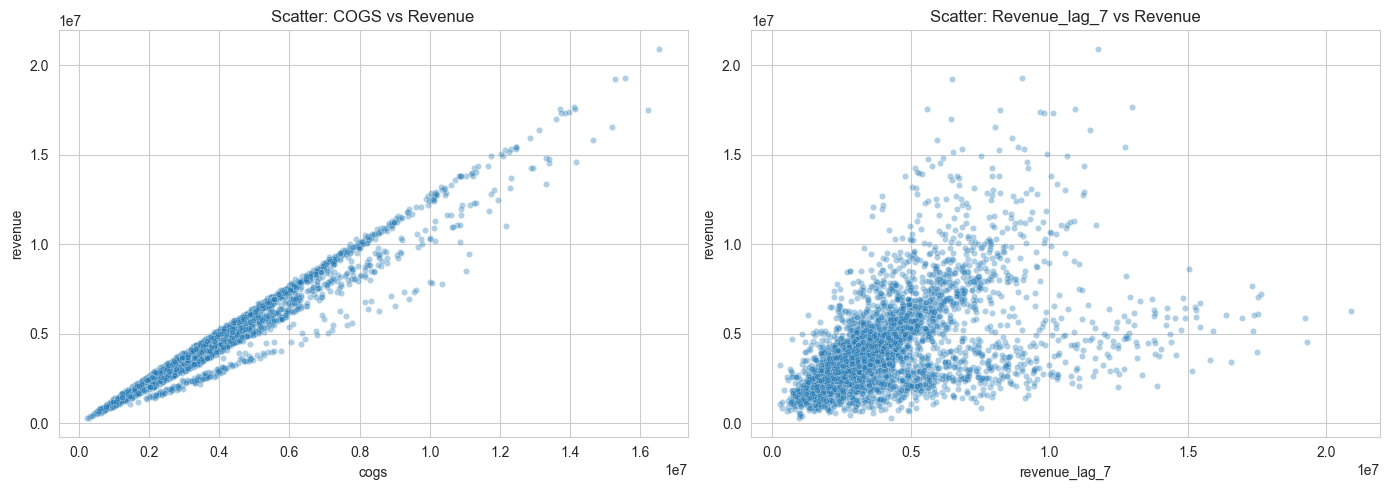

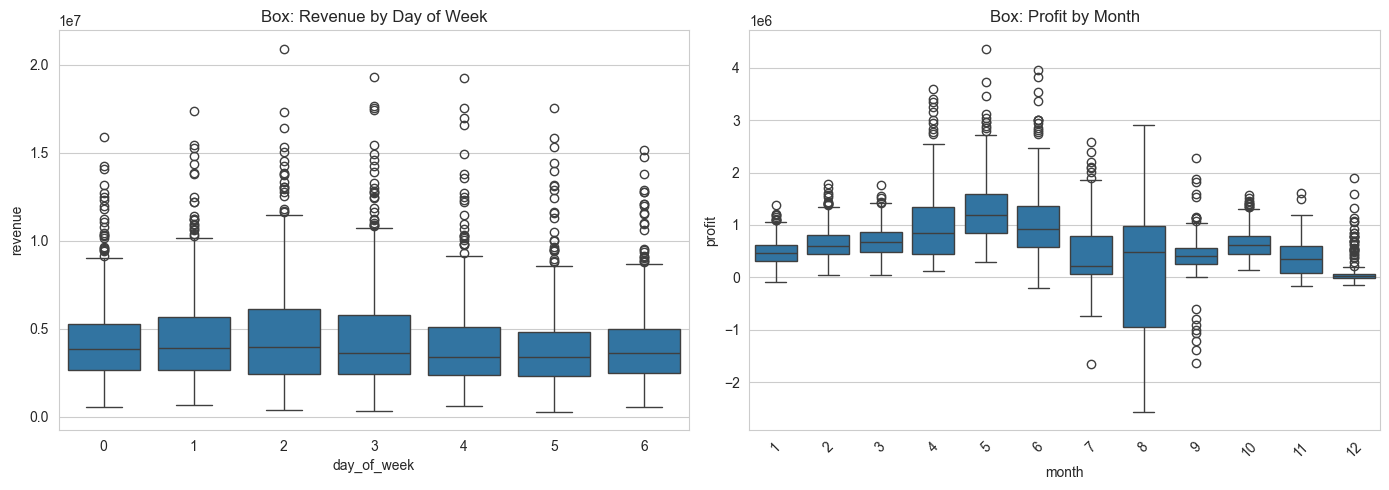

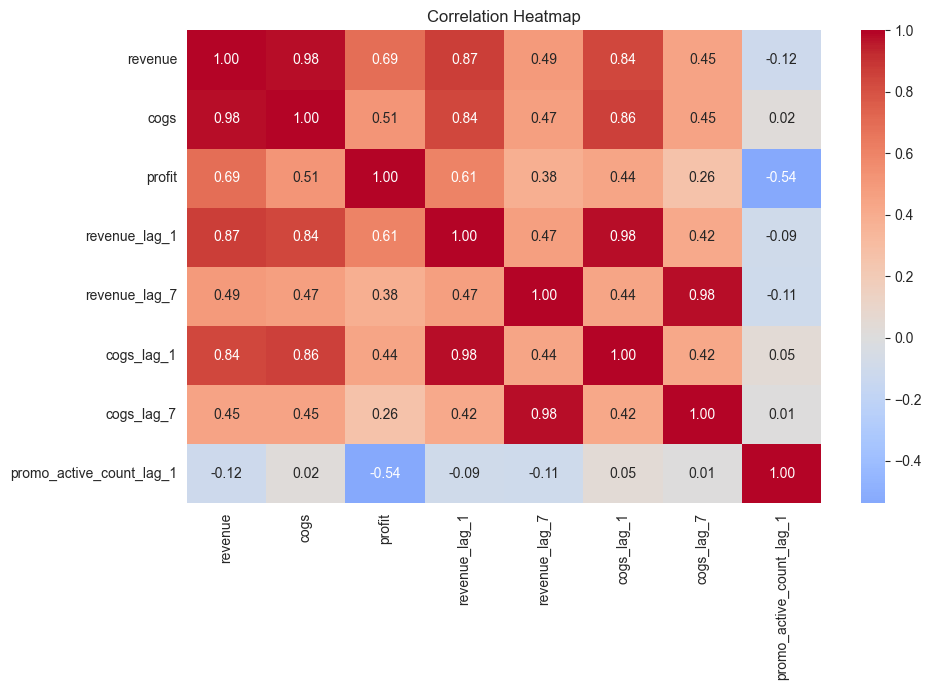

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# thêm vài biến hỗ trợ
df_plot = df.copy()
df_plot["month"] = df_plot["date"].dt.month
df_plot["day_of_week"] = df_plot["date"].dt.dayofweek
df_plot["profit"] = df_plot["revenue"] - df_plot["cogs"]

# 1) Scatter: quan hệ tuyến tính / phi tuyến
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_plot.sample(min(5000, len(df_plot)), random_state=42),
    x="cogs", y="revenue", alpha=0.35, s=20, ax=axes[0]
)
axes[0].set_title("Scatter: COGS vs Revenue")

sns.scatterplot(
    data=df_plot.sample(min(5000, len(df_plot)), random_state=42),
    x="revenue_lag_7", y="revenue", alpha=0.35, s=20, ax=axes[1]
)
axes[1].set_title("Scatter: Revenue_lag_7 vs Revenue")

fig.tight_layout()
fig.savefig(eda_dir / "02_scatter_relationships.png", dpi=150, bbox_inches="tight")
plt.show()

# 2) Box plot: phân phối theo nhóm
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_plot, x="day_of_week", y="revenue", ax=axes[0])
axes[0].set_title("Box: Revenue by Day of Week")

sns.boxplot(data=df_plot, x="month", y="profit", ax=axes[1])
axes[1].set_title("Box: Profit by Month")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(eda_dir / "03_box_relationships.png", dpi=150, bbox_inches="tight")
plt.show()

# 3) Heatmap tương quan
corr_cols = [
    "revenue", "cogs", "profit",
    "revenue_lag_1", "revenue_lag_7",
    "cogs_lag_1", "cogs_lag_7",
    "promo_active_count_lag_1",
]
corr_cols = [c for c in corr_cols if c in df_plot.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(df_plot[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(eda_dir / "04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Skewness:
revenue          1.670004
revenue_lag_7    1.668146
cogs             1.625134
cogs_lag_7       1.623116
dtype: float64


,skewness,nhan_xet
revenue,1.670004,Lệch phải
revenue_lag_7,1.668146,Lệch phải
cogs,1.625134,Lệch phải
cogs_lag_7,1.623116,Lệch phải


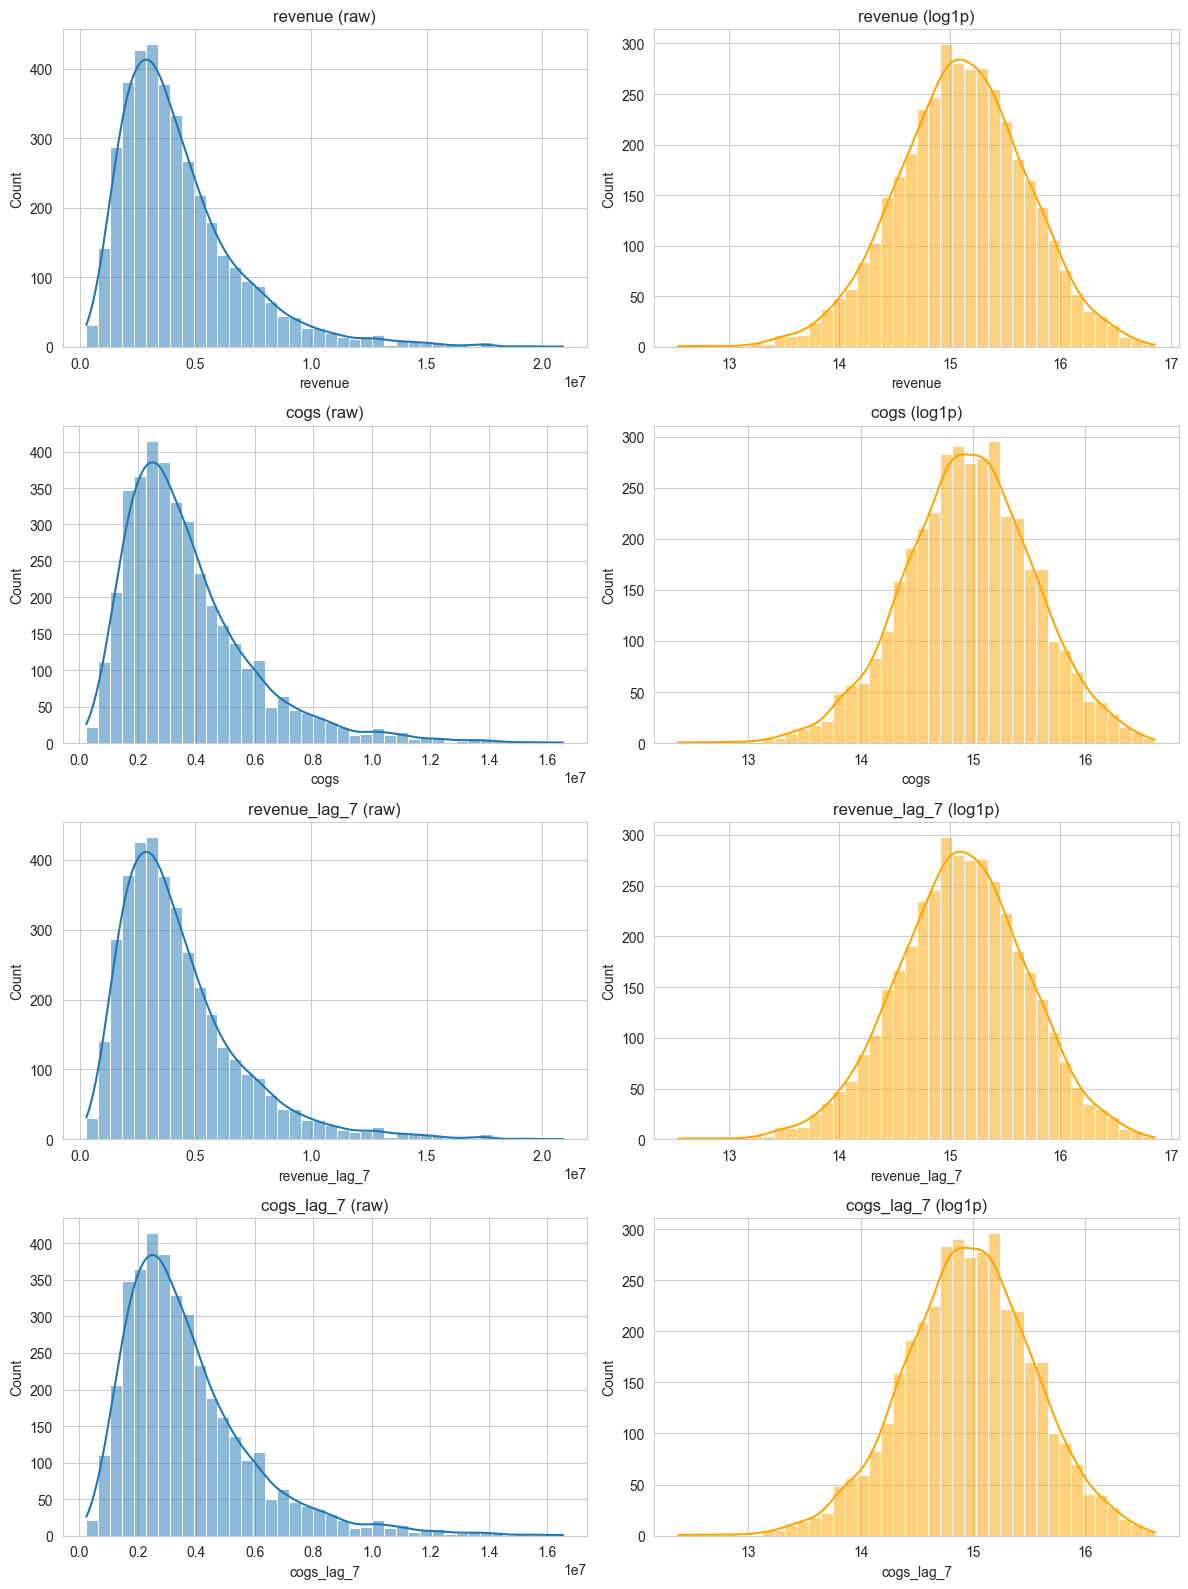

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# chọn biến số cần kiểm tra (đổi theo dataset của bạn)
num_cols = [c for c in ["revenue", "cogs", "profit", "revenue_lag_7", "cogs_lag_7"] if c in df.columns]

# 1) đo skewness (lệch)
sk = df[num_cols].skew(numeric_only=True).sort_values(ascending=False)
print("Skewness:")
print(sk)

def skew_label(v):
    if v > 0.5:
        return "Lệch phải"
    if v < -0.5:
        return "Lệch trái"
    return "Gần đối xứng"

summary = pd.DataFrame({
    "skewness": sk,
    "nhan_xet": sk.map(skew_label)
})
display(summary)

# 2) histogram + KDE để nhìn trực quan
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))
if n == 1:
    axes = np.array([axes])

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], bins=40)
    axes[i, 0].set_title(f"{col} (raw)")

    # 3) log1p cho biến dương để giảm lệch phải
    s = df[col].dropna()
    if (s >= 0).all():
        sns.histplot(np.log1p(s), kde=True, ax=axes[i, 1], bins=40, color="orange")
        axes[i, 1].set_title(f"{col} (log1p)")
    else:
        axes[i, 1].axis("off")
        axes[i, 1].set_title(f"{col}: có giá trị âm, bỏ qua log1p")

fig.tight_layout()
fig.savefig(eda_dir / "05_distribution_skewness.png", dpi=150, bbox_inches="tight")
plt.show()

Top tương quan với revenue:


revenue                             1.000000
cogs                                0.975994
revenue_lag_1                       0.865494
line_net_total_lag_1                0.861219
payment_value_total_lag_1           0.861219
cogs_lag_1                          0.836483
order_count_lag_1                   0.818596
line_net_total_roll_mean_7          0.696054
payment_value_total_roll_mean_7     0.696054
revenue_roll_mean_7                 0.695158
line_net_total_roll_mean_14         0.670727
payment_value_total_roll_mean_14    0.670727
revenue_roll_mean_14                0.669986
revenue_roll_mean_28                0.664985
payment_value_total_roll_mean_28    0.661499
Name: revenue, dtype: float64

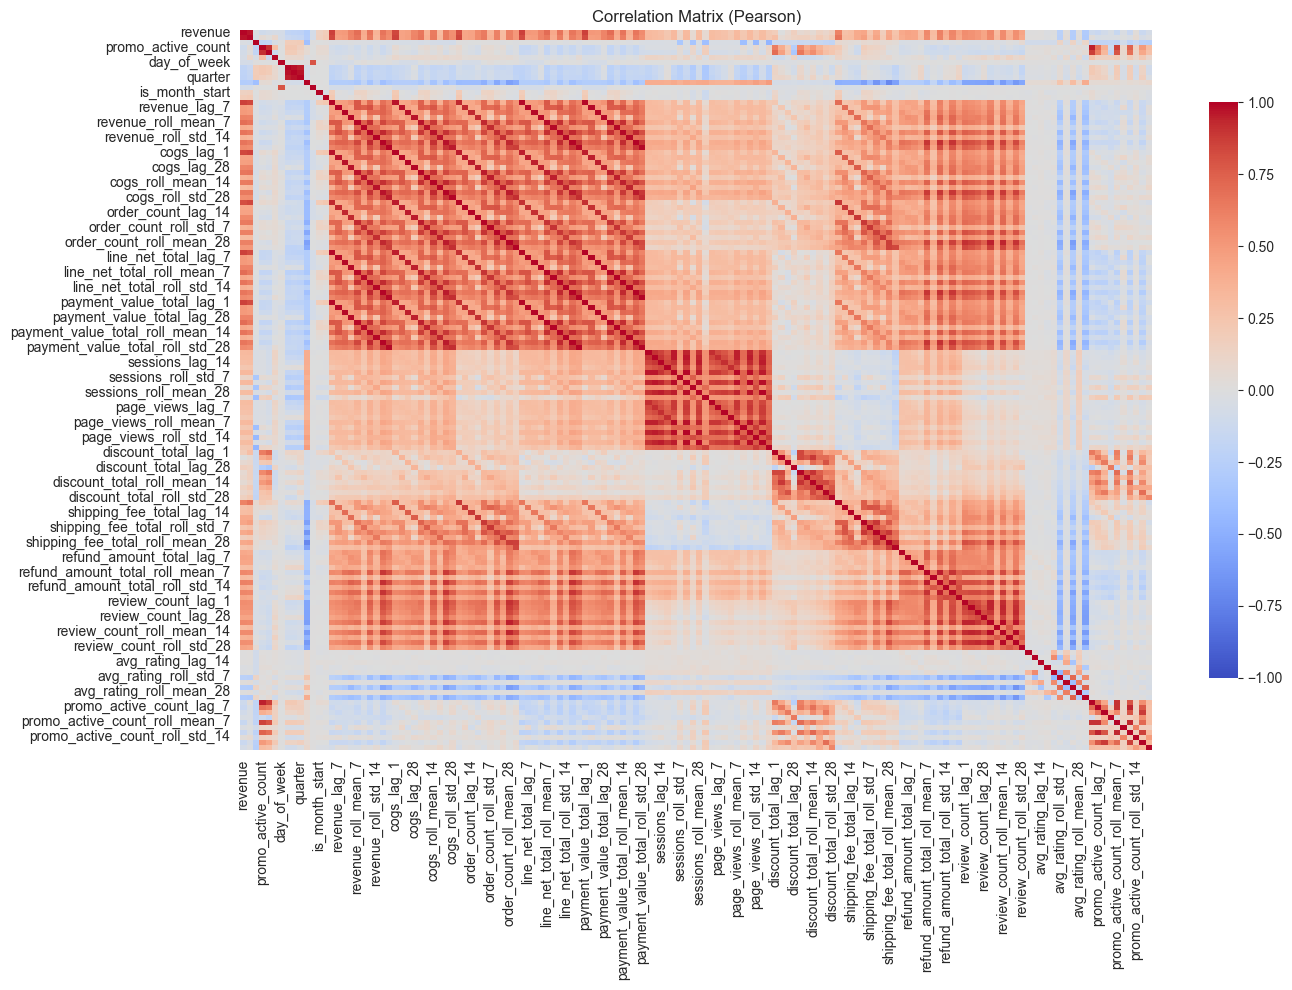

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# lấy toàn bộ cột số
num_df = df.select_dtypes(include=[np.number]).copy()

# bỏ cột có 1 giá trị duy nhất (không có ý nghĩa tương quan)
num_df = num_df.loc[:, num_df.nunique(dropna=True) > 1]

# ma trận tương quan Pearson
corr = num_df.corr(method="pearson")

# hiển thị nhanh top tương quan với Revenue (nếu có)
if "revenue" in corr.columns:
    print("Top tương quan với revenue:")
    display(corr["revenue"].sort_values(ascending=False).head(15))

# vẽ heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix (Pearson)")
plt.tight_layout()
plt.savefig(eda_dir / "06_correlation_matrix_full.png", dpi=150, bbox_inches="tight")
plt.show()

Tổng số ô thiếu: 1924
Số cột có missing: 130


,missing_count,missing_pct
sessions_lag_28,28,0.730498
line_net_total_roll_std_28,28,0.730498
line_net_total_roll_mean_28,28,0.730498
payment_value_total_roll_std_28,28,0.730498
payment_value_total_lag_28,28,0.730498
payment_value_total_roll_mean_28,28,0.730498
sessions_roll_std_28,28,0.730498
order_count_roll_mean_28,28,0.730498
line_net_total_lag_28,28,0.730498
cogs_roll_mean_28,28,0.730498


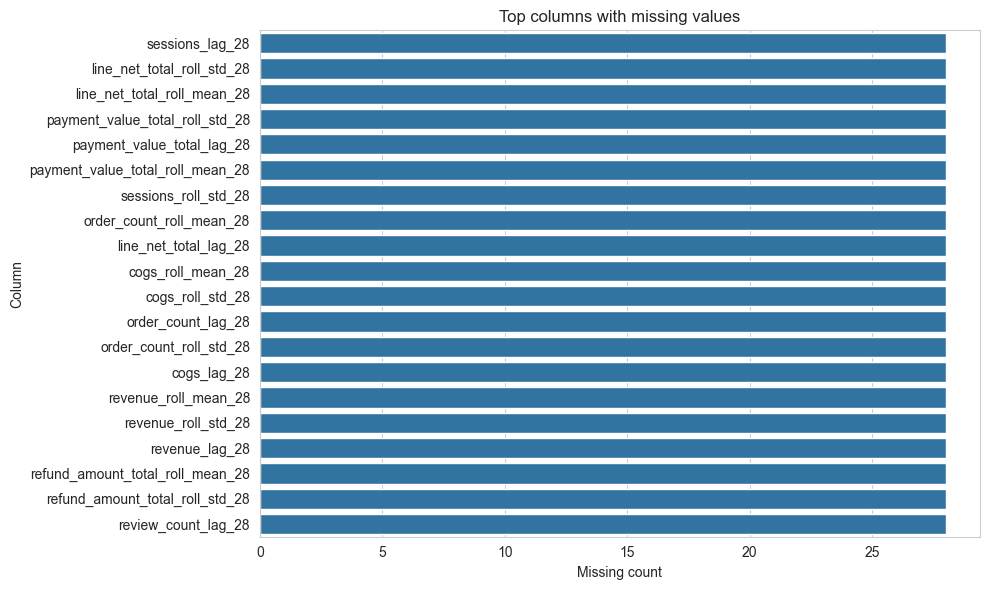

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đếm thiếu theo cột
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

# In tổng quan
print("Tổng số ô thiếu:", int(df.isna().sum().sum()))
print("Số cột có missing:", int((missing_count > 0).sum()))
display(missing_summary[missing_summary["missing_count"] > 0].head(30))

# Vẽ top cột thiếu nhiều nhất (nếu có)
top_missing = missing_summary[missing_summary["missing_count"] > 0].head(20)

if not top_missing.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_missing["missing_count"], y=top_missing.index, orient="h")
    plt.title("Top columns with missing values")
    plt.xlabel("Missing count")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.savefig(eda_dir / "07_missing_values_top.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Không có missing values trong dataframe này.")